In [ ]:
import random
import time
import matplotlib.pyplot as plt


def merge_count(arr, temp, left, mid, right):

    i = left
    j = mid + 1
    k = left

    inversions = 0

    while i <= mid and j <= right:

        if arr[i] <= arr[j]:
            temp[k] = arr[i]
            i += 1

        else:
            temp[k] = arr[j]
            j += 1
            inversions += mid - i + 1

        k += 1

    while i <= mid:
        temp[k] = arr[i]
        i += 1
        k += 1

    while j <= right:
        temp[k] = arr[j]
        j += 1
        k += 1

    for i in range(left, right + 1):
        arr[i] = temp[i]

    return inversions


def count_inversions(arr, temp, left, right):

    if left >= right:
        return 0

    mid = (left + right) // 2

    count = 0

    count += count_inversions(arr, temp, left, mid)
    count += count_inversions(arr, temp, mid + 1, right)
    count += merge_count(arr, temp, left, mid, right)

    return count


sizes = list(range(100, 10001, 500))

avg_times = []

runs = 10

for size in sizes:

    original = [
        random.randint(1, 100000)
        for _ in range(size)
    ]

    total_time = 0

    for _ in range(runs):

        arr = original.copy()
        temp = [0] * size

        start = time.perf_counter_ns()

        count_inversions(arr, temp, 0, size - 1)

        end = time.perf_counter_ns()

        total_time += end - start

    avg_times.append(total_time / runs)


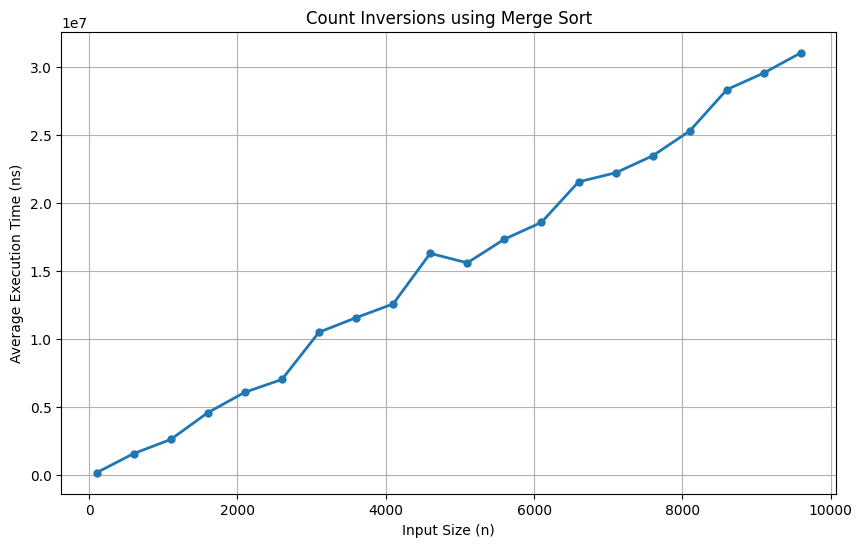

In [6]:
plt.figure(figsize=(10, 6))

plt.plot(
    sizes,
    avg_times,
    marker='o',
    linewidth=2,
    markersize=5
)

plt.title("Count Inversions using Merge Sort")
plt.xlabel("Input Size (n)")
plt.ylabel("Average Execution Time (ns)")
plt.grid(True)

plt.show()